In [4]:
data <- readRDS("/mnt/lareaulab/reliscu/projects/Chronocell/data/janssens_2025_preprint/GSE279232_seuratObj_VBO_4-12.rds")

In [3]:
expr_RNA <- data$RNA@scale.data
expr_ADT <- data$ADT@scale.data

# expr_RNA_filt <- expr_RNA[tolower(rownames(expr_RNA)) %in% tolower(rownames(expr_ADT)),]
# expr_ADT_filt <- expr_ADT[tolower(rownames(expr_ADT)) %in% tolower(rownames(expr_RNA_filt)),]
# genes_lower <- tolower(rownames(expr_ADT_filt))

# for (gene in genes_lower) {

#     subset_RNA <- expr_RNA_filt[tolower(rownames(expr_RNA_filt)) %in% gene,]
#     subset_ADT <- expr_ADT_filt[tolower(rownames(expr_ADT_filt)) %in% gene,]
#     print(paste(toupper(gene), "cor =", cor(subset_ADT, subset_RNA)))

# }

[1] "CD8A cor = 0.287022922926308"
[1] "CD200 cor = 0.249823245119185"
[1] "CD69 cor = 0.124360315138769"
[1] "IRF4 cor = 0.00166257478451715"
[1] "CD14 cor = 0.0711660039180442"
[1] "CD48 cor = 0.0934622212789871"
[1] "CXCR4 cor = 0.0291755013542996"
[1] "CD63 cor = 0.404144439792937"
[1] "CD79B cor = 0.000774970319796991"
[1] "CX3CR1 cor = -0.00294933791939658"
[1] "MERTK cor = -0.00227784542532036"
[1] "XCR1 cor = 0.0702462124279547"
[1] "JAML cor = 0.0442962675300233"


In [5]:
expr_RNA <- data$RNA@counts
expr_ADT <- data$ADT@counts 

expr_RNA_filt <- expr_RNA[tolower(rownames(expr_RNA)) %in% tolower(rownames(expr_ADT)),]
expr_ADT_filt <- expr_ADT[tolower(rownames(expr_ADT)) %in% tolower(rownames(expr_RNA_filt)),]


In [ ]:
mask <- Matrix::rowMeans(expr_RNA_filt) >= .3 
expr_RNA_filt_hi <- expr_RNA_filt[mask,]

In [10]:
genes_lower <- tolower(rownames(expr_RNA_filt))

cors = c()

for (gene in genes_lower) {

    subset_RNA <- expr_RNA_filt[tolower(rownames(expr_RNA_filt)) %in% gene,]
    subset_ADT <- expr_ADT_filt[tolower(rownames(expr_ADT_filt)) %in% gene,]
    print(paste(toupper(gene), "cor =", cor(subset_ADT, subset_RNA)))
    cors <- c(cors, cor(subset_ADT, subset_RNA)) 

}

[1] "CD28 cor = -0.000546620759801582"
[1] "CXCR4 cor = 0.0251223076488247"
[1] "CD55 cor = 0.0234438060662171"
[1] "CD48 cor = 0.110512137977729"
[1] "CD34 cor = 0.00343958390713972"
[1] "MERTK cor = -0.00177590427456033"
[1] "CD93 cor = -0.000828241206085147"
[1] "P2RY12 cor = 0.00725257944659636"
[1] "CD2 cor = 0.0139370842006348"
[1] "TLR4 cor = -0.00420603660108412"
[1] "CD36 cor = 0.00911242287558117"
[1] "CD38 cor = 0.0708980688516074"
[1] "CD8A cor = 0.255020243145647"
[1] "CD163 cor = 0.0190507611518851"
[1] "CD4 cor = 0.136849651935834"
[1] "CD27 cor = -0.00133256205647447"
[1] "CD9 cor = 0.1342529146122"
[1] "CD69 cor = 0.110527532290588"
[1] "CD22 cor = 0.0277168452015941"


Warning message in cor(subset_ADT, subset_RNA):
“the standard deviation is zero”


[1] "GABRB3 cor = NA"


Warning message in cor(subset_ADT, subset_RNA):
“the standard deviation is zero”


[1] "CD19 cor = -0.00167762916987818"
[1] "ENPP1 cor = 0.00514197540811795"
[1] "MADCAM1 cor = 0.00111196806867868"
[1] "CD63 cor = 0.355545189692403"
[1] "ESAM cor = 0.0317144640231614"
[1] "JAML cor = 0.0519930995128024"
[1] "CX3CR1 cor = -0.00256848714708757"
[1] "XCR1 cor = 0.0664688306978742"
[1] "CD68 cor = 0.0176635923985769"
[1] "CD300LG cor = 0.0104113323991153"
[1] "CD79B cor = 0.000406777222577936"
[1] "IRF4 cor = 0.00194070503270813"
[1] "CD83 cor = 0.0714704232921927"
[1] "LY6G cor = -0.0011058740518134"
[1] "CD86 cor = 0.344870399540769"
[1] "CD80 cor = 0.284163531201374"
[1] "TIGIT cor = -0.00160020825601949"
[1] "CD200R3 cor = 0.00196415925936569"
[1] "CD200 cor = 0.287525619941256"
[1] "DLL1 cor = 0.0144986306097015"
[1] "CD14 cor = 0.0800902185331548"
[1] "CD226 cor = 0.0617076912475836"
[1] "CD5 cor = 0.0386211712854936"
[1] "CD274 cor = 0.246040912637589"


In [ ]:
shared_genes_df <- data.frame(Gene=rownames(expr_RNA_filt_hi))

write.csv(shared_genes_df, file="RNA_ADT_shared_genes_meanExpr>0.3.csv", row.names=FALSE, quote=FALSE)

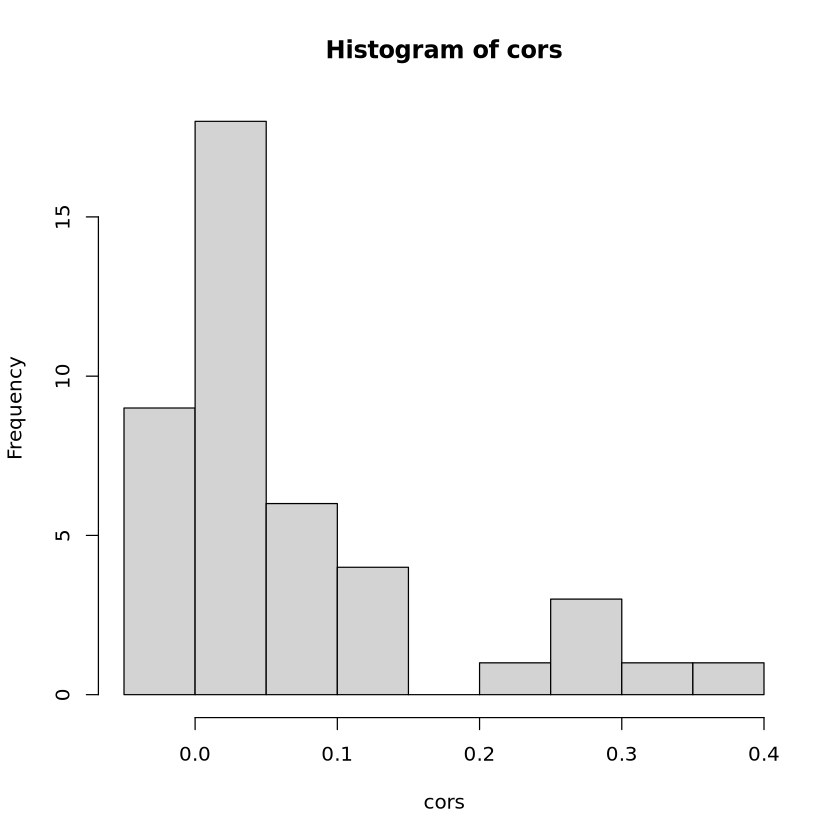

In [12]:
hist(cors)